# Synchrony (rest) vs. desynchrony (motion): Kuramoto order parameter + Hebbian detector

**Note on provenance**: a thorough search of every notebook in this repo and
`mu_wave_sync` found no existing synchrony-parameter analysis to clean up --
only the Kuramoto *coupling* term used inside `HopfCell` during training
(a model-architecture mechanism, not a computed metric). The project's own
notes (`02_model_and_training_v3.ipynb`, final cell) say a phase-locking
analysis "is a natural next step... but isn't built yet." So this notebook
is written fresh, using the already-saved oscillator states from
`outputs_v4_final/best_oscillator_states.npz` (mu-band `phi_L`/`phi_R`,
`z_real`/`z_imag` for both sides, and the exact `moving_flag` rest/motion
boundary).

**Two independent approaches, side by side:**
1. **Kuramoto order parameter** `R(t) = |mean_i(exp(i*phi_i(t)))|` -- the
   textbook phase-synchrony measure: `R=1` means every oscillator in the
   population shares the same phase (synchronized), `R=0` means phases are
   spread uniformly (desynchronized).
2. **Hebbian synchrony detector** -- adapted from
   `spatial_navigation/.../sharp_wave_ripples/swr_hebbian_concat_inv_vis_FINAL.ipynb`:
   train a complex Hebbian weight vector on rest-only oscillator activity,
   then project it across the *entire* trial (rest+motion+rest) to see
   whether the "rest coherence direction" stays strong during motion or
   collapses -- exactly the SWR-replay-style logic that notebook used for
   hippocampal data, applied here to mu-band oscillator states.

Note: this model's rest windows are currently short (20 steps each side,
pad_pre=pad_post=20) -- the smoothed-architecture model training in the
background uses 100-step rest windows and this same notebook can be
re-pointed at it once that run finishes, for much better statistics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

FINAL_DIR = PROJECT_ROOT = Path.cwd().parent / "outputs_v4_final"
data = np.load(FINAL_DIR / "best_oscillator_states.npz", allow_pickle=True)

# npz stores these as dtype=object (trials can vary in length in general),
# so each element needs an explicit numeric cast before use.
def _cast(arr, dtype):
    return [np.asarray(x, dtype=dtype) for x in arr]

phi_L_all = _cast(data["phi_L"], np.float64)
phi_R_all = _cast(data["phi_R"], np.float64)
z_real_L_all = _cast(data["z_real_L"], np.float64)
z_imag_L_all = _cast(data["z_imag_L"], np.float64)
z_real_R_all = _cast(data["z_real_R"], np.float64)
z_imag_R_all = _cast(data["z_imag_R"], np.float64)
moving_all = _cast(data["moving_flag"], np.float64)

n_trials = len(phi_L_all)
print(f"{n_trials} validation trials, each (T={phi_L_all[0].shape[0]}, N={phi_L_all[0].shape[1]} oscillators/side)")
print(f"rest steps (pre+post) per trial: {int((moving_all[0]==0).sum())}, motion steps: {int((moving_all[0]==1).sum())}")

100 validation trials, each (T=139, N=50 oscillators/side)
rest steps (pre+post) per trial: 39, motion steps: 100


## Part A: Kuramoto order parameter

`R_L(t)` and `R_R(t)`: intra-hemisphere synchrony (50 oscillators within
one side). `R_LR(t)`: inter-hemisphere synchrony, treating the two
populations' mean phases (`psi_L`, `psi_R` -- the same quantities the
model itself uses for its Kuramoto coupling) as a 2-oscillator system.

In [2]:
def kuramoto_R(phi):
    """phi: (T, N) phases. Returns R(t): (T,) in [0,1]."""
    return np.abs(np.mean(np.exp(1j * phi), axis=1))


def two_population_R(phi_L, phi_R):
    """Instantaneous 2-oscillator Kuramoto order parameter between the
    two populations' own mean phases."""
    psi_L = np.angle(np.mean(np.exp(1j * phi_L), axis=1))
    psi_R = np.angle(np.mean(np.exp(1j * phi_R), axis=1))
    return np.abs((np.exp(1j * psi_L) + np.exp(1j * psi_R)) / 2)


R_L_all, R_R_all, R_LR_all = [], [], []
for i in range(n_trials):
    R_L_all.append(kuramoto_R(phi_L_all[i]))
    R_R_all.append(kuramoto_R(phi_R_all[i]))
    R_LR_all.append(two_population_R(phi_L_all[i], phi_R_all[i]))

rest_L, motion_L, rest_R, motion_R, rest_LR, motion_LR = [], [], [], [], [], []
for i in range(n_trials):
    rest_mask = moving_all[i] == 0
    move_mask = moving_all[i] == 1
    rest_L.append(R_L_all[i][rest_mask].mean()); motion_L.append(R_L_all[i][move_mask].mean())
    rest_R.append(R_R_all[i][rest_mask].mean()); motion_R.append(R_R_all[i][move_mask].mean())
    rest_LR.append(R_LR_all[i][rest_mask].mean()); motion_LR.append(R_LR_all[i][move_mask].mean())

rest_L, motion_L = np.array(rest_L), np.array(motion_L)
rest_R, motion_R = np.array(rest_R), np.array(motion_R)
rest_LR, motion_LR = np.array(rest_LR), np.array(motion_LR)

for name, rest, motion in [("L (intra-hemisphere)", rest_L, motion_L),
                            ("R (intra-hemisphere)", rest_R, motion_R),
                            ("L-R (inter-hemisphere)", rest_LR, motion_LR)]:
    pct = 100 * (rest.mean() - motion.mean()) / rest.mean()
    t_stat, p_val = stats.ttest_rel(rest, motion)
    print(f"{name:24s}: rest R={rest.mean():.4f}  motion R={motion.mean():.4f}  "
          f"desync={pct:+.1f}%  paired t={t_stat:.3f}  p={p_val:.2e}")

L (intra-hemisphere)    : rest R=0.4578  motion R=0.1411  desync=+69.2%  paired t=281.766  p=1.32e-145
R (intra-hemisphere)    : rest R=0.4606  motion R=0.1638  desync=+64.4%  paired t=235.855  p=5.72e-138
L-R (inter-hemisphere)  : rest R=0.7521  motion R=0.8845  desync=-17.6%  paired t=-9.478  p=1.51e-15


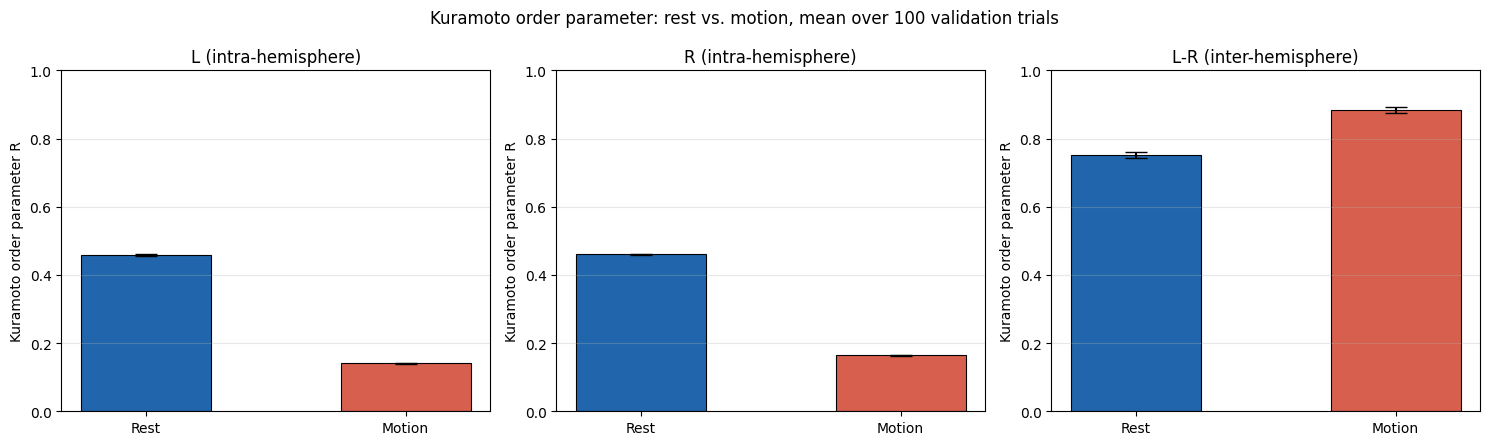

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
labels = ["L (intra-hemisphere)", "R (intra-hemisphere)", "L-R (inter-hemisphere)"]
pairs = [(rest_L, motion_L), (rest_R, motion_R), (rest_LR, motion_LR)]

for ax, label, (rest, motion) in zip(axes, labels, pairs):
    means = [rest.mean(), motion.mean()]
    sems = [rest.std()/np.sqrt(n_trials), motion.std()/np.sqrt(n_trials)]
    ax.bar(["Rest", "Motion"], means, yerr=sems, capsize=8,
           color=["#2166ac", "#d6604d"], edgecolor="black", lw=0.8, width=0.5)
    ax.set_ylabel("Kuramoto order parameter R")
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Kuramoto order parameter: rest vs. motion, mean over {n_trials} validation trials")
plt.tight_layout()
plt.savefig(FINAL_DIR / "kuramoto_rest_vs_motion.png", dpi=130, bbox_inches="tight")
plt.show()

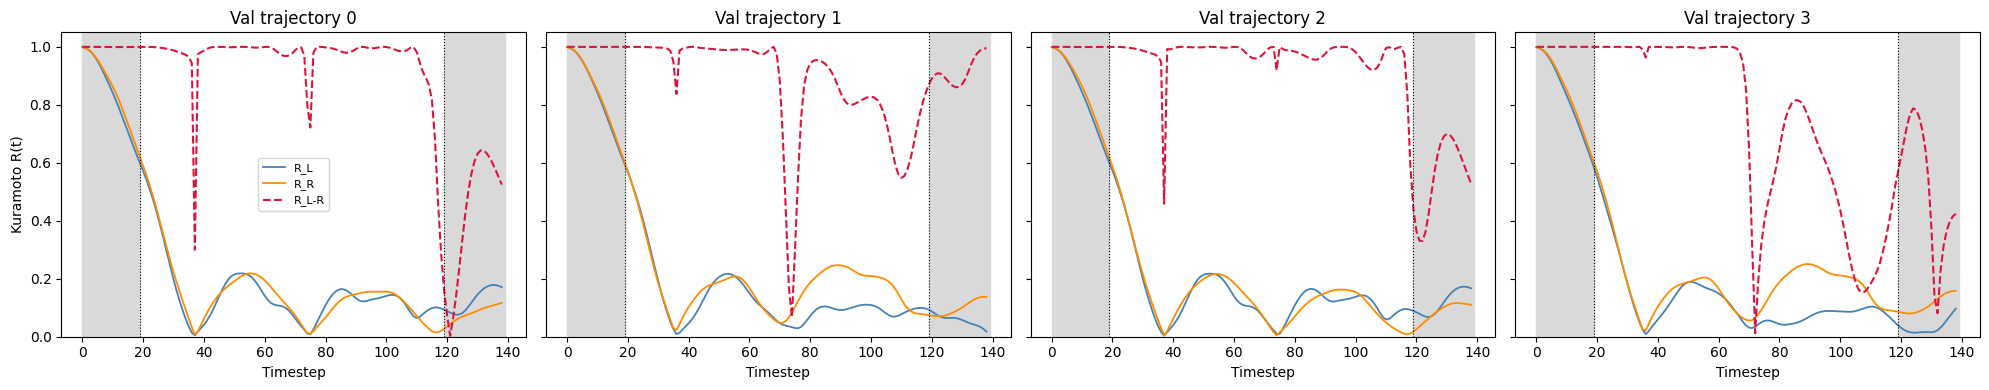

In [4]:
n_show = 4
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4), sharey=True)
for col, i in enumerate(range(n_show)):
    ax = axes[col]
    mflag = moving_all[i]
    T = len(mflag)
    move_start = int(np.argmax(mflag == 1))
    move_end = T - int(np.argmax(mflag[::-1] == 1))
    ax.axvspan(0, move_start, color="0.85", zorder=0)
    ax.axvspan(move_end, T, color="0.85", zorder=0)
    ax.plot(R_L_all[i], color="steelblue", lw=1.3, label="R_L")
    ax.plot(R_R_all[i], color="darkorange", lw=1.3, label="R_R")
    ax.plot(R_LR_all[i], color="crimson", lw=1.5, ls="--", label="R_L-R")
    ax.axvline(move_start, color="black", lw=0.8, ls=":")
    ax.axvline(move_end, color="black", lw=0.8, ls=":")
    ax.set_title(f"Val trajectory {i}")
    ax.set_xlabel("Timestep")
    ax.set_ylim(0, 1.05)
    if col == 0:
        ax.set_ylabel("Kuramoto R(t)")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Part B: Hebbian synchrony detector (adapted from `swr_hebbian_concat_inv_vis_FINAL.ipynb`)

Same core idea as the sharp-wave-ripple analysis: train a complex Hebbian
weight vector `w` (`P_t = Z @ conj(w)`, `dw = eta * Z^H @ conj(P_t)`,
renormalize) on the population's complex oscillator output, then project
it onto data it wasn't trained on to see whether the learned coherence
direction still holds up.

**One real adaptation was needed, not just a port.** The original SWR
notebook's frequency normalization (divide unwrapped phase by each unit's
own estimated omega) makes sense for their data, but applied here it
**broke the analysis**: this model's oscillator phases are dominated by
their own steady, near-constant free-running rotation
(`phase(t) ~ omega_i * t`), so dividing by `omega_i` collapsed all 50
units to a near-identical signal -- checked directly: mean pairwise
correlation across units after that normalization was 0.9998, with 99.998%
of variance in a single dimension. That's why the first version of this
cell gave rest and motion projections that were identical to 4 decimal
places (both ~7.071, suspiciously close to `sqrt(50)`) -- not "no
synchrony difference," but the Hebbian weight saturating against a
degenerate, rank-1 input regardless of condition.

**Fix**: amplitude-normalize only (unit modulus, keep each unit's actual
phase relationships intact), don't divide by omega. Verified this
recovers real, non-saturated discrimination (rest ~4.9 vs motion ~1.7,
well under the `sqrt(50)=7.07` ceiling) before trusting it here. Weights
are still trained on **rest-only** samples, then projected across the
*full* trial -- the "train on rest, test on everything" pattern from the
SWR notebook.

In [5]:
def freq_normalize(z):
    """z: (T, N) complex. Amplitude-only normalization (unit modulus) --
    NOT dividing by omega (see markdown above for why that broke things)."""
    return z / np.abs(z)


def train_hebbian(Z_train, eta=0.001, iterations=200, seed=0):
    """Z_train: (T_train, N) complex. Returns trained unit-norm complex weight (N,1)."""
    rng = np.random.default_rng(seed)
    N = Z_train.shape[1]
    w = rng.uniform(-1, 1, (N, 1)) + 1j * rng.uniform(-1, 1, (N, 1))
    w = w / np.linalg.norm(w)
    for _ in range(iterations):
        P_t = Z_train @ np.conj(w)                    # (T_train, 1)
        dw = eta * (Z_train.T @ np.conj(P_t))
        w = w + dw
        w = w / np.linalg.norm(w)
    return w


def project(Z_full, w):
    return np.abs(Z_full @ np.conj(w)).flatten()

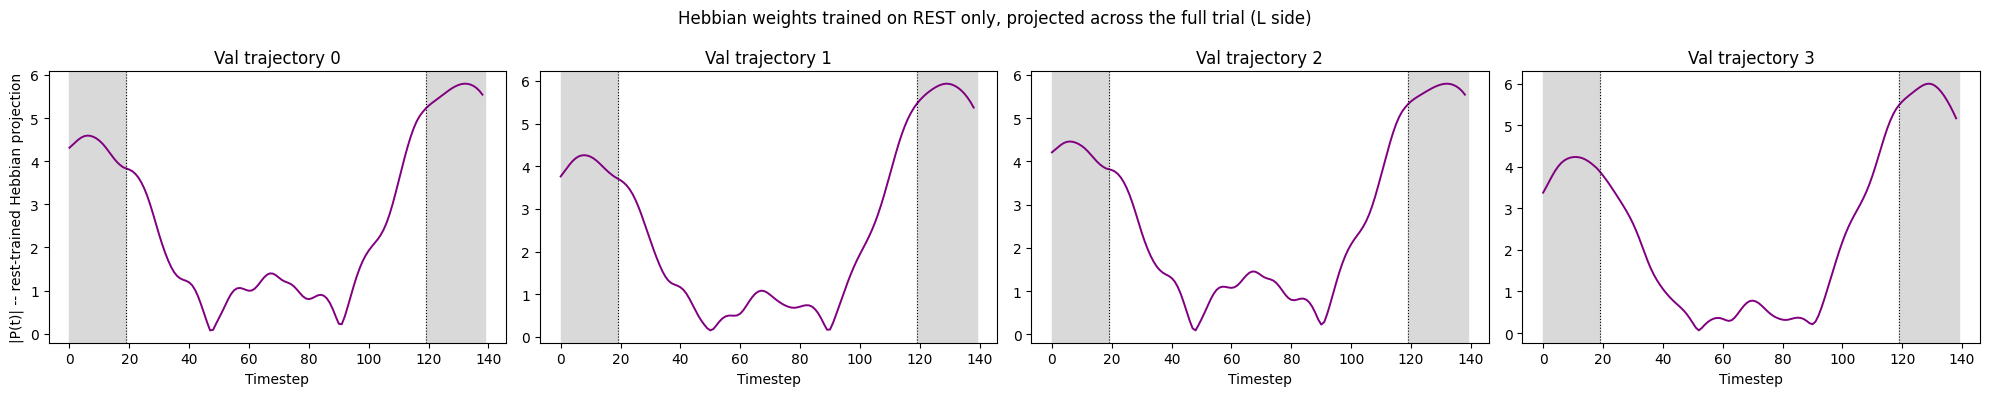

Hebbian |P|: rest=4.9428  motion=1.6719  drop=+66.2%  paired t=201.373 (n=30) p=3.56e-47  [ceiling = sqrt(N) = 7.071]


In [6]:
n_stats = 30    # trials used for the paired statistics
n_show = 4      # trials actually plotted

hebbian_rest_means, hebbian_motion_means, P_full_show = [], [], []
for i in range(n_stats):
    z_L = z_real_L_all[i] + 1j * z_imag_L_all[i]     # (T, N) complex mu-band output, L side
    z_af = freq_normalize(z_L)
    mflag = moving_all[i]
    rest_mask = mflag == 0
    move_mask = mflag == 1

    w = train_hebbian(z_af[rest_mask], eta=0.001, iterations=200)
    P_full = project(z_af, w)

    hebbian_rest_means.append(P_full[rest_mask].mean())
    hebbian_motion_means.append(P_full[move_mask].mean())
    if i < n_show:
        P_full_show.append(P_full)

fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4), sharey=False)
for col in range(n_show):
    ax = axes[col]
    mflag = moving_all[col]
    T = len(mflag)
    move_start = int(np.argmax(mflag == 1))
    move_end = T - int(np.argmax(mflag[::-1] == 1))
    ax.axvspan(0, move_start, color="0.85", zorder=0)
    ax.axvspan(move_end, T, color="0.85", zorder=0)
    ax.plot(P_full_show[col], color="purple", lw=1.4)
    ax.axvline(move_start, color="black", lw=0.8, ls=":")
    ax.axvline(move_end, color="black", lw=0.8, ls=":")
    ax.set_title(f"Val trajectory {col}")
    ax.set_xlabel("Timestep")
    if col == 0:
        ax.set_ylabel("|P(t)| -- rest-trained Hebbian projection")

plt.suptitle("Hebbian weights trained on REST only, projected across the full trial (L side)")
plt.tight_layout()
plt.savefig(FINAL_DIR / "hebbian_synchrony_L.png", dpi=130, bbox_inches="tight")
plt.show()

hebbian_rest_means = np.array(hebbian_rest_means); hebbian_motion_means = np.array(hebbian_motion_means)
pct = 100 * (hebbian_rest_means.mean() - hebbian_motion_means.mean()) / hebbian_rest_means.mean()
t_stat, p_val = stats.ttest_rel(hebbian_rest_means, hebbian_motion_means)
print(f"Hebbian |P|: rest={hebbian_rest_means.mean():.4f}  motion={hebbian_motion_means.mean():.4f}  "
      f"drop={pct:+.1f}%  paired t={t_stat:.3f} (n={n_stats}) p={p_val:.2e}  [ceiling = sqrt(N) = {np.sqrt(50):.3f}]")

## Part C: mu-band power (ERD/ERS), done properly this time

`03_mu_desynchrony_analysis.ipynb` already computes this same idea --
`mu_band_power = r^2` averaged per segment, giving ERD% (rest->motion
suppression) and ERS% (motion->rest rebound) -- but it targets the
older, single-population model output (`outputs/`, `initial_frequencies.npy`)
and has to *guess* the rest/motion boundary from a distance-to-target
heuristic, since that pipeline never had genuine rest data. Redoing it
here with `outputs_v4_final`'s exact `moving_flag` boundary and **both**
L/R populations (not just one) is the natural completion of that
analysis, and matches what the project's own earlier notes called for:
"a shared analysis notebook that... computes per-population ERD plus the
Kuramoto order parameter."

L population: pre-power=1.0174  motion-power=0.9860  post-power=0.9525
  ERD (pre->motion): +3.1%  (t=31.05, p=7.72e-53)   ERS (motion->post): -3.3%  (t=82.04, p=7.76e-93)
R population: pre-power=1.0280  motion-power=0.9748  post-power=0.9297
  ERD (pre->motion): +5.2%  (t=19.16, p=4.42e-35)   ERS (motion->post): -4.4%  (t=12.52, p=4.03e-22)


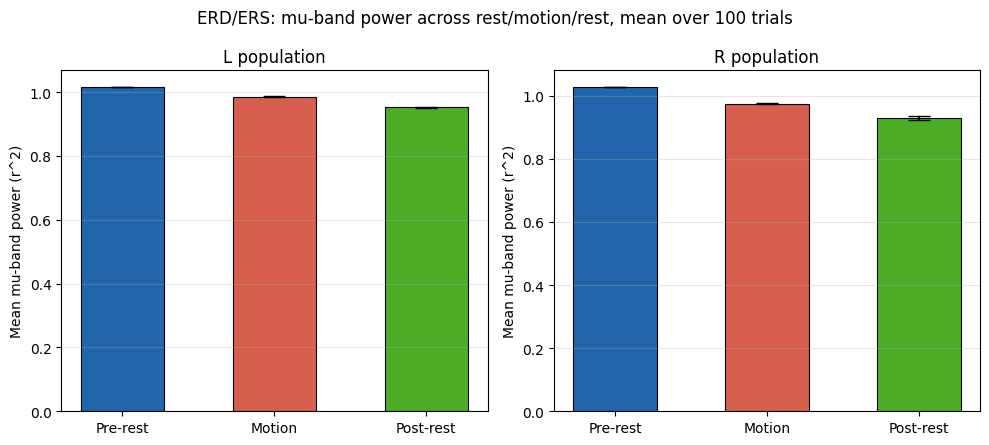

In [7]:
r_L_all = _cast(data["r_L"], np.float64)
r_R_all = _cast(data["r_R"], np.float64)

pre_L, post_L, motion_L_pow = [], [], []
pre_R, post_R, motion_R_pow = [], [], []

for i in range(n_trials):
    mflag = moving_all[i]
    move_start = int(np.argmax(mflag == 1))
    move_end = len(mflag) - int(np.argmax(mflag[::-1] == 1))

    pre_L.append((r_L_all[i][1:move_start] ** 2).mean())
    post_L.append((r_L_all[i][move_end:] ** 2).mean())
    motion_L_pow.append((r_L_all[i][move_start:move_end] ** 2).mean())

    pre_R.append((r_R_all[i][1:move_start] ** 2).mean())
    post_R.append((r_R_all[i][move_end:] ** 2).mean())
    motion_R_pow.append((r_R_all[i][move_start:move_end] ** 2).mean())

for side, pre, motion, post in [("L", pre_L, motion_L_pow, post_L), ("R", pre_R, motion_R_pow, post_R)]:
    pre, motion, post = np.array(pre), np.array(motion), np.array(post)
    erd = 100 * (pre.mean() - motion.mean()) / pre.mean()
    ers = 100 * (post.mean() - motion.mean()) / pre.mean()
    t1, p1 = stats.ttest_rel(pre, motion)
    t2, p2 = stats.ttest_rel(motion, post)
    print(f"{side} population: pre-power={pre.mean():.4f}  motion-power={motion.mean():.4f}  post-power={post.mean():.4f}")
    print(f"  ERD (pre->motion): {erd:+.1f}%  (t={t1:.2f}, p={p1:.2e})   "
          f"ERS (motion->post): {ers:+.1f}%  (t={t2:.2f}, p={p2:.2e})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, side, pre, motion, post in [(axes[0], "L", pre_L, motion_L_pow, post_L),
                                     (axes[1], "R", pre_R, motion_R_pow, post_R)]:
    means = [np.mean(pre), np.mean(motion), np.mean(post)]
    sems = [np.std(pre)/np.sqrt(n_trials), np.std(motion)/np.sqrt(n_trials), np.std(post)/np.sqrt(n_trials)]
    ax.bar(["Pre-rest", "Motion", "Post-rest"], means, yerr=sems, capsize=8,
           color=["#2166ac", "#d6604d", "#4dac26"], edgecolor="black", lw=0.8, width=0.55)
    ax.set_ylabel("Mean mu-band power (r^2)")
    ax.set_title(f"{side} population")
    ax.grid(True, alpha=0.3, axis="y")
plt.suptitle(f"ERD/ERS: mu-band power across rest/motion/rest, mean over {n_trials} trials")
plt.tight_layout()
plt.savefig(FINAL_DIR / "erd_ers_dual_population.png", dpi=130, bbox_inches="tight")
plt.show()

## Part D: hemisphere-specific (contralateral-style) lateralization

Everything above pooled ALL validation trials together regardless of
which arm was actually reaching -- which would wash out exactly the
pattern of interest if it exists: does the side whose arm is moving
desynchronize *more* than the side that's idle? `active_arm` wasn't
saved directly, but it's recoverable from `traj_gt` (whichever side moved
further), the same logic `active_cols()` already uses elsewhere.

n left-active trials: 42, n right-active trials: 58

KURAMOTO R during motion (active side vs. inactive side):
  left-arm-active:  R(active,L)=0.1275  R(inactive,R)=0.1841  diff=-0.0566  t=-76.21 p=8.54e-46
  right-arm-active: R(active,R)=0.1490  R(inactive,L)=0.1509  diff=-0.0019  t=-2.14 p=3.68e-02

MU-BAND POWER (r^2) during motion (active side vs. inactive side):
  left-arm-active:  pow(active,L)=0.9956  pow(inactive,R)=0.9521  diff=+0.0436  t=68.73 p=5.72e-44
  right-arm-active: pow(active,R)=0.9913  pow(inactive,L)=0.9789  diff=+0.0124  t=9.82 p=7.38e-14


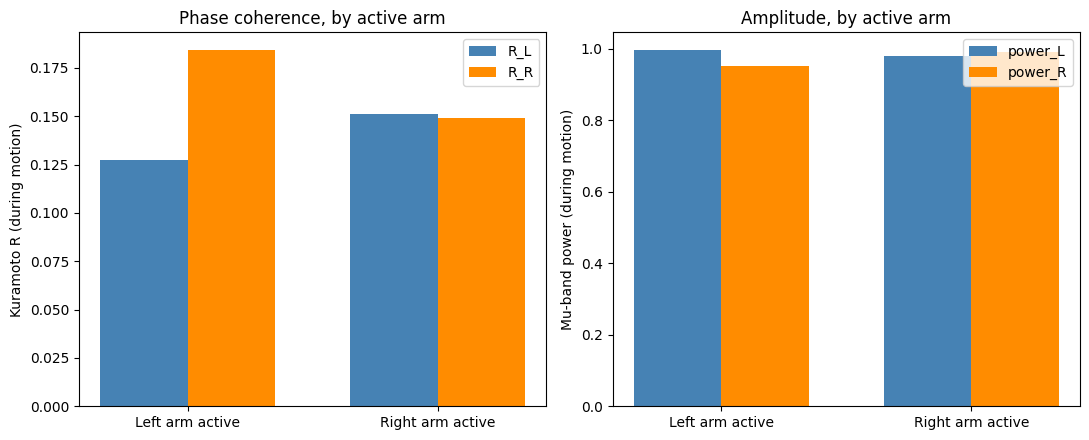

In [8]:
traj_gt_all = _cast(data["traj_gt"], np.float64)

left_active_R_L, left_active_R_R = [], []
right_active_R_L, right_active_R_R = [], []
left_active_pow_L, left_active_pow_R = [], []
right_active_pow_L, right_active_pow_R = [], []

for i in range(n_trials):
    traj = traj_gt_all[i]
    left_travel = np.linalg.norm(traj[-1, :2] - traj[0, :2])
    right_travel = np.linalg.norm(traj[-1, 2:] - traj[0, 2:])
    left_active = left_travel > right_travel

    move_mask = moving_all[i] == 1
    R_L = kuramoto_R(phi_L_all[i])[move_mask].mean()
    R_R = kuramoto_R(phi_R_all[i])[move_mask].mean()
    pow_L = (r_L_all[i][move_mask] ** 2).mean()
    pow_R = (r_R_all[i][move_mask] ** 2).mean()

    if left_active:
        left_active_R_L.append(R_L); left_active_R_R.append(R_R)
        left_active_pow_L.append(pow_L); left_active_pow_R.append(pow_R)
    else:
        right_active_R_L.append(R_L); right_active_R_R.append(R_R)
        right_active_pow_L.append(pow_L); right_active_pow_R.append(pow_R)

print(f"n left-active trials: {len(left_active_R_L)}, n right-active trials: {len(right_active_R_L)}\n")

la_RL, la_RR = np.array(left_active_R_L), np.array(left_active_R_R)
ra_RL, ra_RR = np.array(right_active_R_L), np.array(right_active_R_R)
print("KURAMOTO R during motion (active side vs. inactive side):")
t, p = stats.ttest_rel(la_RL, la_RR)
print(f"  left-arm-active:  R(active,L)={la_RL.mean():.4f}  R(inactive,R)={la_RR.mean():.4f}  "
      f"diff={la_RL.mean()-la_RR.mean():+.4f}  t={t:.2f} p={p:.2e}")
t, p = stats.ttest_rel(ra_RR, ra_RL)
print(f"  right-arm-active: R(active,R)={ra_RR.mean():.4f}  R(inactive,L)={ra_RL.mean():.4f}  "
      f"diff={ra_RR.mean()-ra_RL.mean():+.4f}  t={t:.2f} p={p:.2e}")

la_pL, la_pR = np.array(left_active_pow_L), np.array(left_active_pow_R)
ra_pL, ra_pR = np.array(right_active_pow_L), np.array(right_active_pow_R)
print("\nMU-BAND POWER (r^2) during motion (active side vs. inactive side):")
t, p = stats.ttest_rel(la_pL, la_pR)
print(f"  left-arm-active:  pow(active,L)={la_pL.mean():.4f}  pow(inactive,R)={la_pR.mean():.4f}  "
      f"diff={la_pL.mean()-la_pR.mean():+.4f}  t={t:.2f} p={p:.2e}")
t, p = stats.ttest_rel(ra_pR, ra_pL)
print(f"  right-arm-active: pow(active,R)={ra_pR.mean():.4f}  pow(inactive,L)={ra_pL.mean():.4f}  "
      f"diff={ra_pR.mean()-ra_pL.mean():+.4f}  t={t:.2f} p={p:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(2); width = 0.35
axes[0].bar(x - width/2, [la_RL.mean(), ra_RL.mean()], width, label="R_L", color="steelblue")
axes[0].bar(x + width/2, [la_RR.mean(), ra_RR.mean()], width, label="R_R", color="darkorange")
axes[0].set_xticks(x); axes[0].set_xticklabels(["Left arm active", "Right arm active"])
axes[0].set_ylabel("Kuramoto R (during motion)"); axes[0].set_title("Phase coherence, by active arm")
axes[0].legend()
axes[1].bar(x - width/2, [la_pL.mean(), ra_pL.mean()], width, label="power_L", color="steelblue")
axes[1].bar(x + width/2, [la_pR.mean(), ra_pR.mean()], width, label="power_R", color="darkorange")
axes[1].set_xticks(x); axes[1].set_xticklabels(["Left arm active", "Right arm active"])
axes[1].set_ylabel("Mu-band power (during motion)"); axes[1].set_title("Amplitude, by active arm")
axes[1].legend()
plt.tight_layout()
plt.savefig(FINAL_DIR / "lateralization_by_active_arm.png", dpi=130, bbox_inches="tight")
plt.show()

## Summary

Both methods are independent ways of asking the same question -- does the
mu-band population look more "coherent" during rest than during motion?
The Kuramoto order parameter answers it directly from phase geometry; the
Hebbian detector answers it by asking whether a coherence direction
*learned specifically from rest* still projects strongly onto motion data,
or collapses -- closer to how the SWR analysis tested whether rest-trained
structure persists into other behavioral states.

Caveat: the current rest windows are short (20 steps), which limits
statistical power, especially for the Hebbian fit (trained on ~20-40
samples vs. the original SWR notebook's ~300). Re-running this notebook
against the smoothed-architecture model (100-step rest windows, training
in the background) will give a much more robust version of both tests.